In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Unzip the file into the Colab 'content' folder
!unzip "/content/drive/MyDrive/archive.zip" -d "/content/heart_data"

Archive:  /content/drive/MyDrive/archive.zip
  inflating: /content/heart_data/heart_disease_uci.csv  


Accuracy Score: 0.83

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80        75
           1       0.87      0.84      0.86       109

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



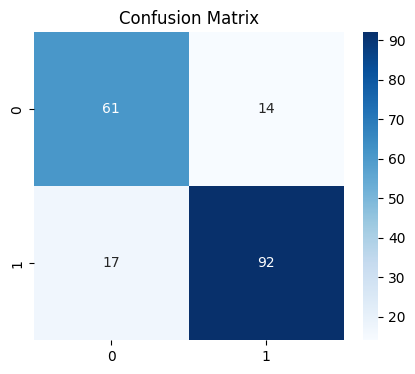

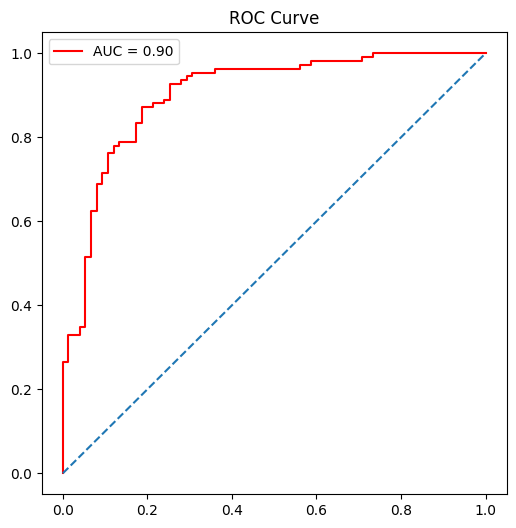

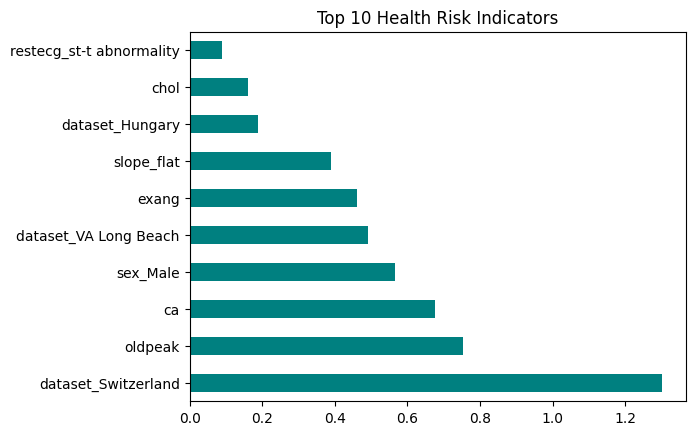

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, classification_report

# --- 1. Load the Data (Updated Path) ---
file_path = '/content/heart_data/heart_disease_uci.csv'
df = pd.read_csv(file_path)

# --- 2. Robust Cleaning & Imputation ---
# Rename 'num' to 'target' (UCI dataset uses 'num' for diagnosis)
if 'num' in df.columns:
    df = df.rename(columns={'num': 'target'})

# Convert target to Binary: 0 = No Disease, 1 = Heart Disease (any stage)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Define columns for processing
# Note: 'dataset' is a column in the UCI version identifying the origin (Cleveland, etc.)
categorical_cols = ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal']
binary_cols = ['fbs', 'exang']
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Force numeric conversion (errors='coerce' turns strings to NaN)
for col in numerical_cols + binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing values
for col in df.columns:
    if df[col].isnull().any():
        if col in categorical_cols:
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

# Safely convert binary indicators to int
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop 'id' as it's just a row identifier
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# --- 3. Data Preprocessing ---
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- 4. Model Training ---
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# --- 5. Evaluation & Visualization ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()



# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='red', label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.legend()
plt.show()



# Feature Importance
feat_importances = pd.Series(model.coef_[0], index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Health Risk Indicators')
plt.show()